# GPT-2 124M — 5-Class Review-Score Fine-tune
**Dataset**: Olist translated reviews → `review_score` 1–5  
**GPU target**: RTX 5060 Ti 16 GB (sm_120, Blackwell, CUDA 13)

> **One-time setup — run once in terminal before this notebook:**
> ```bash
> python extract_gpt2_weights.py
> ```
> Saves `gpt2/gpt2_124M_weights.npz` using TensorFlow (CPU-only).  
> This notebook is **100 % TensorFlow-free** — that prevents CUDA-context crashes on Blackwell.


In [1]:
import os, json, time, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import tiktoken
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {device}')
if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability()
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'Compute  : sm_{cap[0]}{cap[1]}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    print('TF32 matmul : enabled')


PyTorch  : 2.12.0+cu130
Device   : cuda
GPU      : NVIDIA GeForce RTX 5060 Ti
Compute  : sm_120
VRAM     : 16.6 GB
TF32 matmul : enabled


In [2]:
loss_name = 'huber' # Change to 'mse' when you want to test MSE
# ── GPT-2 355M architecture hyperparameters ───────────────────────────────
# 124M: emb_dim=768,  n_heads=12, n_layers=12
# 355M: emb_dim=1024, n_heads=16, n_layers=24  ← this notebook
BASE_CONFIG = {
    'vocab_size'     : 50257,
    'context_length' : 1024,
    'emb_dim'        : 1024,   # 355M
    'n_heads'        : 16,     # 355M
    'n_layers'       : 24,     # 355M
    'drop_rate'      : 0.1,
    'qkv_bias'       : True,
}

CFG = {
    'data_path'          : 'translated_nlp_dataset.jsonl',
    'weights_npz'        : 'gpt2/gpt2_355M_weights.npz',
    'checkpoint_path'    : f'gpt2_355M_{loss_name}_best.pt',    
    'test_results_path'  : f'test_results_355M_{loss_name}.json',
    'num_classes'        : 1,         # <--- CHANGED: 1 output scalar for regression
    'loss_type'          : 'huber',   # <--- ADDED: 'huber' or 'mse'
    'huber_delta'        : 1.0,       # <--- ADDED: parameter for Huber loss
    'max_length'         : 256,
    'unfreeze_last_n'    : 4,
    'batch_size'         : 16,
    'num_epochs'         : 10,
    'learning_rate'      : 5e-5,
    'weight_decay'       : 0.01,
    'warmup_ratio'       : 0.06,
    'grad_clip'          : 1.0,
    'label_smoothing'    : 0.1,
    'eval_freq'          : 50,
    'eval_iter'          : 20,
    'early_stop_patience': 3,
}
print('Config ready.')


Config ready.


In [3]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps   = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / (var + self.eps).sqrt() + self.shift


class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1.0 + torch.tanh(
            math.sqrt(2.0 / math.pi) * (x + 0.044715 * x.pow(3))))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d = cfg['emb_dim']
        self.layers = nn.Sequential(nn.Linear(d, 4*d), GELU(), nn.Linear(4*d, d))
    def forward(self, x): return self.layers(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0
        self.d_out     = d_out
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads
        self.W_query   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key     = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj  = nn.Linear(d_out, d_out)
        self.dropout   = nn.Dropout(dropout)
        self.register_buffer(
            'mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, t, _ = x.shape
        def proj(w, inp):
            return w(inp).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        q, k, v = proj(self.W_query, x), proj(self.W_key, x), proj(self.W_value, x)
        attn = q @ k.transpose(2, 3) / self.head_dim ** 0.5
        attn.masked_fill_(self.mask.bool()[:t, :t], float('-inf'))
        attn = self.dropout(torch.softmax(attn, dim=-1))
        ctx  = (attn @ v).transpose(1, 2).contiguous().view(b, t, self.d_out)
        return self.out_proj(ctx)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att   = MultiHeadAttention(cfg['emb_dim'], cfg['emb_dim'],
                         cfg['context_length'], cfg['drop_rate'],
                         cfg['n_heads'], cfg['qkv_bias'])
        self.ff    = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg['emb_dim'])
        self.norm2 = LayerNorm(cfg['emb_dim'])
        self.drop  = nn.Dropout(cfg['drop_rate'])

    def forward(self, x):
        x = x + self.drop(self.att(self.norm1(x)))
        x = x + self.drop(self.ff(self.norm2(x)))
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb    = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb    = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        self.drop_emb   = nn.Dropout(cfg['drop_rate'])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg['n_layers'])])
        self.final_norm = LayerNorm(cfg['emb_dim'])
        self.out_head   = nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias=False)  # ← FIXED

    def forward(self, idx):
        b, t = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(t, device=idx.device))
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)


print('Architecture defined.')


Architecture defined.


In [4]:
def inspect_npz_keys(npz_path, max_keys=30):
    """Helper — print actual keys in the .npz so you can debug any future mismatch."""
    w = np.load(npz_path, allow_pickle=False)
    keys = list(w.files)
    print(f'Total keys in npz: {len(keys)}')
    for k in keys[:max_keys]:
        print(f'  {k:50s}  {w[k].shape}')
    if len(keys) > max_keys:
        print(f'  ... and {len(keys)-max_keys} more')


def load_weights_from_npz(gpt, npz_path):
    """
    Load GPT-2 pretrained weights from the .npz saved by extract_gpt2_weights.py.

    extract_gpt2_weights.py builds keys with:
        key = name.split("/", 1)[1].replace("/", "|")
    so  'model/h0/attn/c_attn/w'  →  'h0|attn|c_attn|w'
    and 'model/ln_f/g'            →  'ln_f|g'

    This function uses exactly those key names.
    """
    w = np.load(npz_path, allow_pickle=False)

    # ── Embeddings ─────────────────────────────────────────────────────────
    gpt.tok_emb.weight.data.copy_(torch.from_numpy(w['wte']))   # token embedding
    gpt.pos_emb.weight.data.copy_(torch.from_numpy(w['wpe']))   # positional embedding

    n_layers = int(w['__n_layer__'])
    for b in range(n_layers):
        p = f'h{b}'   # ← CORRECT prefix: 'h0', 'h1', ... not 'blocks|0'

        # ── Attention QKV (fused in TF checkpoint → split into Q / K / V) ─
        c_attn_w = w[f'{p}|attn|c_attn|w']   # (768, 2304)
        c_attn_b = w[f'{p}|attn|c_attn|b']   # (2304,)
        q_w, k_w, v_w = np.split(c_attn_w, 3, axis=-1)   # each (768, 768)
        q_b, k_b, v_b = np.split(c_attn_b, 3)             # each (768,)

        gpt.trf_blocks[b].att.W_query.weight.data.copy_(torch.from_numpy(q_w.T))
        gpt.trf_blocks[b].att.W_key.weight.data.copy_(torch.from_numpy(k_w.T))
        gpt.trf_blocks[b].att.W_value.weight.data.copy_(torch.from_numpy(v_w.T))
        gpt.trf_blocks[b].att.W_query.bias.data.copy_(torch.from_numpy(q_b))
        gpt.trf_blocks[b].att.W_key.bias.data.copy_(torch.from_numpy(k_b))
        gpt.trf_blocks[b].att.W_value.bias.data.copy_(torch.from_numpy(v_b))

        # ── Attention output projection ─────────────────────────────────────
        gpt.trf_blocks[b].att.out_proj.weight.data.copy_(
            torch.from_numpy(w[f'{p}|attn|c_proj|w'].T))
        gpt.trf_blocks[b].att.out_proj.bias.data.copy_(
            torch.from_numpy(w[f'{p}|attn|c_proj|b']))

        # ── MLP ─────────────────────────────────────────────────────────────
        gpt.trf_blocks[b].ff.layers[0].weight.data.copy_(
            torch.from_numpy(w[f'{p}|mlp|c_fc|w'].T))
        gpt.trf_blocks[b].ff.layers[0].bias.data.copy_(
            torch.from_numpy(w[f'{p}|mlp|c_fc|b']))
        gpt.trf_blocks[b].ff.layers[2].weight.data.copy_(
            torch.from_numpy(w[f'{p}|mlp|c_proj|w'].T))
        gpt.trf_blocks[b].ff.layers[2].bias.data.copy_(
            torch.from_numpy(w[f'{p}|mlp|c_proj|b']))

        # ── Layer norms ─────────────────────────────────────────────────────
        gpt.trf_blocks[b].norm1.scale.data.copy_(torch.from_numpy(w[f'{p}|ln_1|g']))
        gpt.trf_blocks[b].norm1.shift.data.copy_(torch.from_numpy(w[f'{p}|ln_1|b']))
        gpt.trf_blocks[b].norm2.scale.data.copy_(torch.from_numpy(w[f'{p}|ln_2|g']))
        gpt.trf_blocks[b].norm2.shift.data.copy_(torch.from_numpy(w[f'{p}|ln_2|b']))

    # ── Final layer norm  ('ln_f|g' / 'ln_f|b' — NOT bare 'g' / 'b') ──────
    gpt.final_norm.scale.data.copy_(torch.from_numpy(w['ln_f|g']))
    gpt.final_norm.shift.data.copy_(torch.from_numpy(w['ln_f|b']))

    # ── Weight tying: classifier head shares the token embedding matrix ─────
    gpt.out_head.weight.data.copy_(torch.from_numpy(w['wte']))


# ── Sanity-check: print actual keys so you can verify ─────────────────────
assert os.path.exists(CFG['weights_npz']), (
    f"Weights not found at '{CFG['weights_npz']}'.\n"
    "Run:  python extract_gpt2_weights.py  from a terminal first."
)
print('=== First 30 keys in the .npz (for reference) ===')
inspect_npz_keys(CFG['weights_npz'])

print('\n=== Loading weights into GPTModel ===')
model = GPTModel(BASE_CONFIG)
load_weights_from_npz(model, CFG['weights_npz'])
model.eval()
print('\nPretrained GPT-2 weights loaded — zero TensorFlow.')


=== First 30 keys in the .npz (for reference) ===
Total keys in npz: 295
  h0|attn|c_attn|b                                    (3072,)
  h0|attn|c_attn|w                                    (1024, 3072)
  h0|attn|c_proj|b                                    (1024,)
  h0|attn|c_proj|w                                    (1024, 1024)
  h0|ln_1|b                                           (1024,)
  h0|ln_1|g                                           (1024,)
  h0|ln_2|b                                           (1024,)
  h0|ln_2|g                                           (1024,)
  h0|mlp|c_fc|b                                       (4096,)
  h0|mlp|c_fc|w                                       (1024, 4096)
  h0|mlp|c_proj|b                                     (1024,)
  h0|mlp|c_proj|w                                     (4096, 1024)
  h1|attn|c_attn|b                                    (3072,)
  h1|attn|c_attn|w                                    (1024, 3072)
  h1|attn|c_proj|b                

In [5]:
records = []
with open(CFG['data_path']) as f:
    for line in f:
        obj   = json.loads(line)
        text  = obj.get('english_translation', '').strip()
        score = obj.get('review_score')
        if text and score is not None:
            records.append({
                'order_id': obj.get('order_id', ''),
                'text'    : text,
                'label'   : int(score) - 1,
            })

df = pd.DataFrame(records)
print(f'Total samples : {len(df)}')
print('\nLabel distribution (0=score1 … 4=score5):')
print(df['label'].value_counts().sort_index())


Total samples : 44209

Label distribution (0=score1 … 4=score5):
label
0     9446
1     2477
2     3961
3     6401
4    21924
Name: count, dtype: int64


In [6]:
train_df, tmp_df  = train_test_split(df,     test_size=0.20, stratify=df['label'],     random_state=SEED)
val_df,   test_df = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df['label'], random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}')


Train 35367 | Val 4421 | Test 4421


In [7]:
tokenizer = tiktoken.get_encoding('gpt2')
PAD_ID    = 50256

class ReviewDataset(Dataset):
    def __init__(self, dataframe, max_length=256, pad_id=PAD_ID):
        self.data       = dataframe.reset_index(drop=True)
        self.max_length = max_length
        self.pad_id     = pad_id
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        row  = self.data.iloc[idx]
        ids  = tokenizer.encode(row['text'])[:self.max_length]
        ids += [self.pad_id] * (self.max_length - len(ids))
        return (torch.tensor(ids, dtype=torch.long),
                torch.tensor(row['label'], dtype=torch.float32)) # <--- CHANGED to float32

train_ds = ReviewDataset(train_df, CFG['max_length'])
val_ds   = ReviewDataset(val_df,   CFG['max_length'])
test_ds  = ReviewDataset(test_df,  CFG['max_length'])
x, y = train_ds[0]
print(f'Sample → tokens {x.shape}, label {y.item()}')


Sample → tokens torch.Size([256]), label 4.0


In [8]:
label_counts  = Counter(train_df['label'].tolist())
n_total       = len(train_df)
class_weights = {c: n_total / (CFG['num_classes'] * cnt) for c, cnt in label_counts.items()}
sample_wts    = [class_weights[int(l)] for l in train_df['label']]
sampler       = WeightedRandomSampler(sample_wts, num_samples=len(sample_wts), replacement=True)

PIN = torch.cuda.is_available()
B   = CFG['batch_size']

train_loader = DataLoader(train_ds, batch_size=B, sampler=sampler,  num_workers=0, pin_memory=PIN)
val_loader   = DataLoader(val_ds,   batch_size=B, shuffle=False,    num_workers=0, pin_memory=PIN)
test_loader  = DataLoader(test_ds,  batch_size=B, shuffle=False,    num_workers=0, pin_memory=PIN)

print(f'Batches → train {len(train_loader)} | val {len(val_loader)} | test {len(test_loader)}')
print('Class weights:', {k+1: f'{v:.3f}' for k, v in class_weights.items()})


Batches → train 2211 | val 277 | test 277
Class weights: {5: '2.016', 4: '6.906', 3: '11.160', 1: '4.680', 2: '17.853'}


In [9]:
for p in model.parameters():
    p.requires_grad = False

torch.manual_seed(SEED)
model.out_head = nn.Linear(BASE_CONFIG['emb_dim'], CFG['num_classes'], bias=False)

N = CFG['unfreeze_last_n']
for block in model.trf_blocks[-N:]:
    for p in block.parameters():
        p.requires_grad = True

for p in model.final_norm.parameters():
    p.requires_grad = True

model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  ({100 * trainable / total:.1f}%)')


Total params     : 354,824,192
Trainable params : 50,387,968  (14.2%)


In [10]:
# 1. Define Loss function
if CFG['loss_type'] == 'huber':
    criterion = nn.HuberLoss(delta=CFG['huber_delta'])
elif CFG['loss_type'] == 'mse':
    criterion = nn.MSELoss()

# 2. Calculate Batch Loss
def calc_loss_batch(xb, yb):
    # Slice [:, -1, 0] to grab the single scalar output instead of [:, -1, :]
    preds = model(xb.to(device))[:, -1, 0] 
    return criterion(preds, yb.to(device, dtype=torch.float32))

# 3. Calculate Loss over Loader
@torch.no_grad()
def calc_loss_loader(loader, num_batches=None):
    model.eval()
    total, n = 0.0, 0
    limit = len(loader) if num_batches is None else min(num_batches, len(loader))
    for i, (xb, yb) in enumerate(loader):
        if i >= limit: break
        total += calc_loss_batch(xb, yb).item(); n += 1
    model.train()
    return total / n if n else float('nan')

# 4. Calculate Regression Metrics (MAE, RMSE, Rounded Accuracy)
@torch.no_grad()
def calc_metrics_loader(loader, num_batches=None):
    model.eval()
    abs_err, sq_err, correct, total = 0.0, 0.0, 0, 0
    limit = len(loader) if num_batches is None else min(num_batches, len(loader))
    for i, (xb, yb) in enumerate(loader):
        if i >= limit: break
        preds = model(xb.to(device))[:, -1, 0]
        targets = yb.to(device, dtype=torch.float32)
        
        # Regression Errors
        abs_err += torch.sum(torch.abs(preds - targets)).item()
        sq_err += torch.sum((preds - targets) ** 2).item()
        
        # Round predictions and clamp between valid 0 to 4 range
        rounded_preds = torch.round(preds).clamp(0, 4)
        correct += (rounded_preds == targets).sum().item()
        total += targets.size(0)
    model.train()
    
    mae = abs_err / total if total else 0.0
    rmse = math.sqrt(sq_err / total) if total else 0.0
    acc = correct / total if total else 0.0
    return mae, rmse, acc

def evaluate_model(eval_iter):
    return calc_loss_loader(train_loader, eval_iter), calc_loss_loader(val_loader, eval_iter)

print(f"Utilities ready. Using {CFG['loss_type'].upper()} Loss.")

Utilities ready. Using HUBER Loss.


In [11]:
# Concrete list — never a lazy filter() generator
trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f'Trainable param tensors : {len(trainable_params)}')

_cap       = torch.cuda.get_device_capability() if torch.cuda.is_available() else (0, 0)
_use_fused = torch.cuda.is_available() and (_cap[0] >= 7)

optimizer = torch.optim.AdamW(
    trainable_params,
    lr           = CFG['learning_rate'],
    weight_decay = CFG['weight_decay'],
    betas        = (0.9, 0.95),
    fused        = _use_fused,
)
print(f'AdamW fused : {_use_fused}  (sm_{_cap[0]}{_cap[1]})')

total_steps  = CFG['num_epochs'] * len(train_loader)
warmup_steps = int(CFG['warmup_ratio'] * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * prog)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f'Total steps : {total_steps}  |  Warmup : {warmup_steps}')


Trainable param tensors : 67
AdamW fused : True  (sm_120)
Total steps : 22110  |  Warmup : 1326


In [12]:
def train_classifier():
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_val_loss  = float('inf')
    patience_count = 0
    global_step    = -1

    for epoch in range(CFG['num_epochs']):
        model.train()
        t0 = time.time()

        for xb, yb in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss = calc_loss_batch(xb, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, CFG['grad_clip'])
            optimizer.step()
            scheduler.step()
            global_step += 1

            if global_step % CFG['eval_freq'] == 0:
                tr_l, vl_l = evaluate_model(CFG['eval_iter'])
                train_losses.append(tr_l)
                val_losses.append(vl_l)
                lr_now = scheduler.get_last_lr()[0]
                print(f'Ep {epoch+1} | Step {global_step:05d} | '
                      f'Train {tr_l:.4f} | Val {vl_l:.4f} | LR {lr_now:.2e}')

        # REMOVE calc_accuracy_loader calls, REPLACE with:
        tr_mae, tr_rmse, tr_acc = calc_metrics_loader(train_loader)
        vl_mae, vl_rmse, vl_acc = calc_metrics_loader(val_loader)
        epoch_vl = calc_loss_loader(val_loader)
        
        train_accs.append(tr_acc)
        val_accs.append(vl_acc)

        elapsed = (time.time() - t0) / 60
        print(f'\n── Epoch {epoch+1}/{CFG["num_epochs"]}  ({elapsed:.1f} min) ──')
        print(f'   Train MAE {tr_mae:.4f}  |  Val MAE {vl_mae:.4f}')
        print(f'   Train RMSE {tr_rmse:.4f} |  Val RMSE {vl_rmse:.4f}')
        print(f'   Train Acc (Round) {tr_acc*100:.2f}% | Val Acc (Round) {vl_acc*100:.2f}%')
        print(f'   Val loss  {epoch_vl:.4f}    |  Best    {best_val_loss:.4f}')

        if epoch_vl < best_val_loss:
            best_val_loss  = epoch_vl
            patience_count = 0
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                        'val_loss': best_val_loss, 'val_acc': vl_acc},
                       CFG['checkpoint_path'])
            print(f'   ✓ Checkpoint saved  (val_loss={best_val_loss:.4f})')
        else:
            patience_count += 1
            print(f'   No improvement — patience {patience_count}/{CFG["early_stop_patience"]}')
            if patience_count >= CFG['early_stop_patience']:
                print('\nEarly stopping triggered.'); break
        print()

    return train_losses, val_losses, train_accs, val_accs

print('Trainer defined.')


Trainer defined.


In [13]:
print('=== Baseline (before fine-tuning) ===')
b_tr_mae, b_tr_rmse, b_tr_acc = calc_metrics_loader(train_loader, 10)
b_vl_mae, b_vl_rmse, b_vl_acc = calc_metrics_loader(val_loader, 10)

print(f'Train → loss {calc_loss_loader(train_loader, 10):.4f} | MAE {b_tr_mae:.4f} | acc {b_tr_acc*100:.2f}%')
print(f'Val   → loss {calc_loss_loader(val_loader, 10):.4f} | MAE {b_vl_mae:.4f} | acc {b_vl_acc*100:.2f}%')
print()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

t_start = time.time()
train_losses, val_losses, train_accs, val_accs = train_classifier()
print(f'\nTotal training time: {(time.time() - t_start) / 60:.1f} min')


=== Baseline (before fine-tuning) ===
Train → loss 1.0305 | MAE 1.3747 | acc 19.38%
Val   → loss 1.1731 | MAE 1.6459 | acc 8.12%

Ep 1 | Step 00000 | Train 0.9564 | Val 1.1748 | LR 3.77e-08
Ep 1 | Step 00050 | Train 0.9083 | Val 1.3392 | LR 1.92e-06
Ep 1 | Step 00100 | Train 0.8123 | Val 1.3436 | LR 3.81e-06
Ep 1 | Step 00150 | Train 0.8097 | Val 1.2486 | LR 5.69e-06
Ep 1 | Step 00200 | Train 0.7821 | Val 1.2411 | LR 7.58e-06
Ep 1 | Step 00250 | Train 0.7656 | Val 1.0560 | LR 9.46e-06
Ep 1 | Step 00300 | Train 0.7323 | Val 1.0080 | LR 1.13e-05
Ep 1 | Step 00350 | Train 0.6272 | Val 0.9248 | LR 1.32e-05
Ep 1 | Step 00400 | Train 0.6504 | Val 0.8093 | LR 1.51e-05
Ep 1 | Step 00450 | Train 0.6593 | Val 0.8424 | LR 1.70e-05
Ep 1 | Step 00500 | Train 0.5749 | Val 0.7134 | LR 1.89e-05
Ep 1 | Step 00550 | Train 0.6154 | Val 1.0222 | LR 2.08e-05
Ep 1 | Step 00600 | Train 0.5227 | Val 0.6949 | LR 2.27e-05
Ep 1 | Step 00650 | Train 0.4541 | Val 0.6295 | LR 2.45e-05
Ep 1 | Step 00700 | Train 0.46

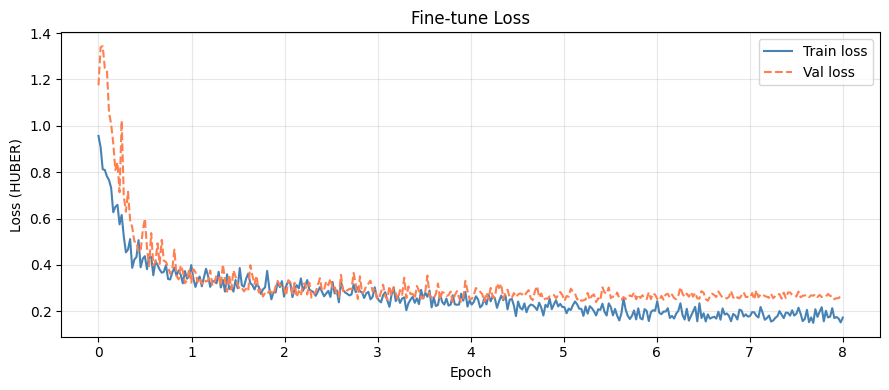

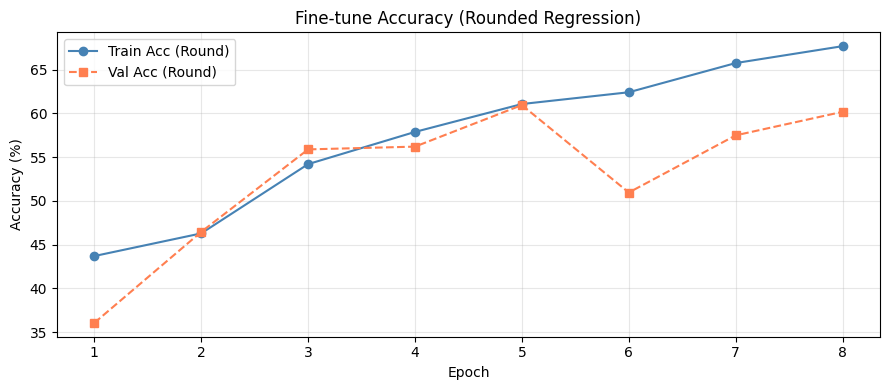

In [14]:
actual_epochs = len(train_accs)

# 1. Plot Loss
fig, ax = plt.subplots(figsize=(9, 4))
steps_x = np.linspace(0, actual_epochs, len(train_losses))
ax.plot(steps_x, train_losses, label='Train loss', color='steelblue')
ax.plot(steps_x, val_losses,   label='Val loss',   color='coral', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel(f'Loss ({CFG["loss_type"].upper()})')
ax.set_title('Fine-tune Loss'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'finetune_loss_124M_{CFG["loss_type"]}.png', dpi=150)
plt.show()

# 2. Plot Rounded Accuracy (or MAE if you saved it)
fig, ax = plt.subplots(figsize=(9, 4))
ep_x = range(1, actual_epochs + 1)
ax.plot(ep_x, [a*100 for a in train_accs], label='Train Acc (Round)', color='steelblue', marker='o')
ax.plot(ep_x, [a*100 for a in val_accs],   label='Val Acc (Round)',   color='coral', marker='s', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Fine-tune Accuracy (Rounded Regression)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'finetune_acc_124M_{CFG["loss_type"]}.png', dpi=150); plt.show()

In [15]:
ckpt = torch.load(CFG['checkpoint_path'], map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded epoch {ckpt.get("epoch", 0)+1} — val_loss {ckpt.get("val_loss", 0):.4f}') 
# (Removed ckpt["val_acc"] print just in case you didn't save it in your updated loop)

print('\n=== Final Metrics (Regression) ===')
for name, loader in [('Train', train_loader), ('Val', val_loader), ('Test', test_loader)]:
    # Unpack the 3 metrics from our new function
    mae, rmse, acc = calc_metrics_loader(loader)
    print(f'  {name:5}: MAE {mae:.4f} | RMSE {rmse:.4f} | Rounded Acc {acc*100:.2f}%')

Loaded epoch 5 — val_loss 0.2464

=== Final Metrics (Regression) ===
  Train: MAE 0.5188 | RMSE 0.7105 | Rounded Acc 61.00%
  Val  : MAE 0.5509 | RMSE 0.7759 | Rounded Acc 60.96%
  Test : MAE 0.5789 | RMSE 0.8157 | Rounded Acc 58.88%


Test set inference: 100%|██████████| 277/277 [01:10<00:00,  3.90it/s]

              precision    recall  f1-score   support

     Score 1       0.81      0.56      0.66       945
     Score 2       0.19      0.48      0.27       248
     Score 3       0.33      0.29      0.31       396
     Score 4       0.29      0.42      0.34       640
     Score 5       0.85      0.72      0.78      2192

    accuracy                           0.59      4421
   macro avg       0.49      0.49      0.47      4421
weighted avg       0.68      0.59      0.62      4421



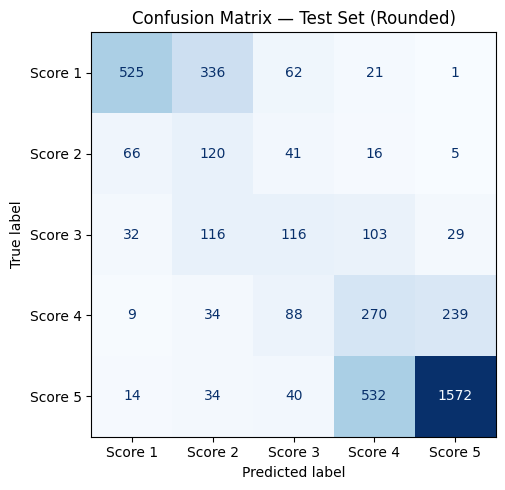

In [16]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc='Test set inference'):
        # Extract scalar output
        preds = model(xb.to(device))[:, -1, 0]
        # Round and clamp to valid classes 0-4
        rounded_preds = torch.round(preds).clamp(0, 4)
        
        all_preds.extend(rounded_preds.cpu().tolist())
        all_labels.extend(yb.tolist())

# Map 0-4 back to Score 1-5
target_names = [f'Score {i+1}' for i in range(CFG['num_classes'] if CFG['num_classes'] > 1 else 5)]
print(classification_report(all_labels, all_preds, target_names=target_names))

cm  = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set (Rounded)')
plt.tight_layout()
plt.savefig(f'confusion_matrix_124M_{CFG["loss_type"]}.png', dpi=150)
plt.show()

In [17]:
RESULTS_PATH = CFG['test_results_path']

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        saved = json.load(f)
    done = {r['sample_index'] for r in saved}
    print(f'Resuming: {len(done)} samples already saved.')
else:
    saved, done = [], set()
    print('Starting fresh.')

model.eval()
global_idx  = 0
new_results = []

for xb, yb in tqdm(test_loader, desc='Saving predictions'):
    B_cur  = xb.size(0)
    to_run = [j for j in range(B_cur) if (global_idx + j) not in done]

    if to_run:
        with torch.no_grad():
            preds = model(xb[to_run].to(device))[:, -1, 0] # Extract the scalar
            rounded_preds = torch.round(preds).clamp(0, 4) # Round and clamp

        for k, j in enumerate(to_run):
            idx = global_idx + j
            row = test_df.iloc[j]
            true = int(yb[j].item())
            
            pred_float = float(preds[k].item())
            pred_int = int(rounded_preds[k].item())
            
            new_results.append({
                'sample_index'   : idx,
                'order_id'       : row.get('order_id', ''),
                'text'           : row['text'],
                'true_score'     : true + 1,
                'predicted_float': round(pred_float + 1, 4), # +1 mapped mapping
                'predicted_score': pred_int + 1,
                'correct'        : true == pred_int,
            })

        combined = saved + new_results
        tmp = RESULTS_PATH + '.tmp'
        with open(tmp, 'w') as f:
            json.dump(combined, f, indent=2, ensure_ascii=False)
        os.replace(tmp, RESULTS_PATH)

    global_idx += B_cur

all_saved = saved + new_results
n_correct  = sum(r['correct'] for r in all_saved)
print(f'\n{len(all_saved)} predictions saved to {RESULTS_PATH}')
print(f'Accuracy from file: {n_correct / len(all_saved) * 100:.2f}%')


Starting fresh.


Saving predictions: 100%|██████████| 277/277 [01:13<00:00,  3.76it/s]


4421 predictions saved to test_results_355M_huber.json
Accuracy from file: 58.88%


  Score | Total | Correct |    Acc
  --------------------------------------
      1 |   945 |     525 |  55.56%
      2 |   248 |     120 |  48.39%
      3 |   396 |     116 |  29.29%
      4 |   640 |     270 |  42.19%
      5 |  2192 |    1572 |  71.72%


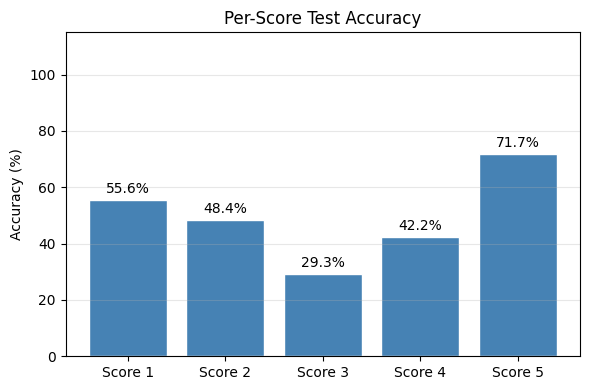

In [18]:
with open(CFG['test_results_path']) as f:
    records = json.load(f)

by_score = {s: {'total': 0, 'correct': 0} for s in range(1, 6)}
for r in records:
    s = r['true_score']
    by_score[s]['total']   += 1
    by_score[s]['correct'] += int(r['correct'])

print(f'  Score | Total | Correct |    Acc')
print('  ' + '-' * 38)
for s in range(1, 6):
    t, c = by_score[s]['total'], by_score[s]['correct']
    print(f'  {s:>5} | {t:>5} | {c:>7} | {c/t*100:>6.2f}%')

scores = list(range(1, 6))
accs   = [by_score[s]['correct'] / by_score[s]['total'] * 100 for s in scores]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([f'Score {s}' for s in scores], accs, color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylim(0, 115); ax.set_ylabel('Accuracy (%)'); ax.set_title('Per-Score Test Accuracy')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'per_score_accuracy_124M_{CFG["loss_type"]}.png', dpi=150)
plt.show()


In [19]:
def predict(text, max_length=256, pad_id=tokenizer.pad_id if hasattr(tokenizer, 'pad_id') else 50256):
    model.eval()
    ids  = tokenizer.encode(text)[:max_length]
    ids += [pad_id] * (max_length - len(ids))
    inp  = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)
    
    with torch.no_grad():
        # Extract the scalar regression prediction
        pred_float = model(inp)[:, -1, 0].item()
    
    # Map 0-4 scale back to 1-5 scale
    actual_score_float = pred_float + 1
    # Round and clamp to 1-5
    pred_int = int(max(1, min(5, round(actual_score_float))))
    
    print(f'Text : {text[:100]}')
    print(f'Pred : Float Score {actual_score_float:.2f}  -->  Bucketed Score {pred_int}')
    print()
    return pred_int


for review in [
    'The product arrived on time and works perfectly. Very happy!',
    'Terrible quality. Broke after one day. Complete waste of money.',
    'Delivery was late but the product itself is okay.',
    'Exceeded my expectations! Fast shipping and great quality.',
    'Not what I expected from the photos, but it works.',
]:
    predict(review)

Text : The product arrived on time and works perfectly. Very happy!
Pred : Float Score 4.99  -->  Bucketed Score 5

Text : Terrible quality. Broke after one day. Complete waste of money.
Pred : Float Score 0.80  -->  Bucketed Score 1

Text : Delivery was late but the product itself is okay.
Pred : Float Score 3.80  -->  Bucketed Score 4

Text : Exceeded my expectations! Fast shipping and great quality.
Pred : Float Score 4.80  -->  Bucketed Score 5

Text : Not what I expected from the photos, but it works.
Pred : Float Score 3.48  -->  Bucketed Score 3



In [20]:
import torch
import os

# Define your exact project path
save_dir = "/home/labib/Desktop/labib_codes/uiu_codes/7th_trimester/da_project/da_project_local/notebooks/nlp_evaluation/gpt2/"

# Ensure the directory exists
os.makedirs(save_dir, exist_ok=True)

# Define the file name for the 355M Huber model
save_path_355M = os.path.join(save_dir, "gpt2_355M_huber_weights.pt")

# Save the PyTorch state dictionary
torch.save(model.state_dict(), save_path_355M)

print(f"✅ 355M Huber Loss Model successfully saved to:\n{save_path_355M}")

✅ 355M Huber Loss Model successfully saved to:
/home/labib/Desktop/labib_codes/uiu_codes/7th_trimester/da_project/da_project_local/notebooks/nlp_evaluation/gpt2/gpt2_355M_huber_weights.pt
